# Stage 6 -- Clustering

**Goal:** assign each of the 30,000 papers to a cluster, using the 100-dim SVD embeddings from Stage 5. We try two methods -- K-Means and HDBSCAN -- and compare them before choosing which to carry forward to Stage 7 (interpretation).

### Why try both?
Stage 5's UMAP plot showed a large, dense, undifferentiated central mass (the cs.LG/cs.AI core) alongside several small, tight, differently-sized satellite clusters. This shape favors a density-based method like **HDBSCAN** over **K-Means**, which assumes roughly spherical, similarly-sized clusters and requires the cluster count k to be chosen in advance. Rather than assuming this upfront, we fit both, compare quantitatively (silhouette score) and visually, and justify the final choice with evidence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

svd_embeddings = np.load("../data/processed/svd_embeddings.npy")
umap_2d = np.load("../data/processed/umap_2d_embeddings.npy")
df = pd.read_parquet("../data/processed/arxiv_with_features_meta.parquet")

print("SVD embeddings:", svd_embeddings.shape)
print("UMAP 2D embeddings:", umap_2d.shape)
print("Metadata:", df.shape)

SVD embeddings: (30000, 100)
UMAP 2D embeddings: (30000, 2)
Metadata: (30000, 7)


## Part A: K-Means

### Step 1: Choose k using the elbow method + silhouette score

We fit K-Means for a range of k values and track both inertia (elbow) and silhouette score. Silhouette score computation is O(n^2)-ish and can be slow on 30,000 points, so we compute it on a random subsample for speed -- this is a standard, defensible practice.

In [2]:
k_range = range(4, 21)
inertias = []
silhouette_scores = []

# Subsample for silhouette score computation (speed) -- fixed seed for reproducibility
rng = np.random.default_rng(42)
sample_idx = rng.choice(svd_embeddings.shape[0], size=5000, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(svd_embeddings)
    inertias.append(km.inertia_)
    sil = silhouette_score(svd_embeddings[sample_idx], labels[sample_idx])
    silhouette_scores.append(sil)
    print(f"k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

k= 4  inertia=4,800  silhouette=0.0420
k= 5  inertia=4,718  silhouette=0.0447
k= 6  inertia=4,663  silhouette=0.0190
k= 7  inertia=4,583  silhouette=0.0186
k= 8  inertia=4,532  silhouette=0.0456
k= 9  inertia=4,461  silhouette=0.0293
k=10  inertia=4,410  silhouette=0.0278
k=11  inertia=4,371  silhouette=0.0287
k=12  inertia=4,313  silhouette=0.0315
k=13  inertia=4,283  silhouette=0.0520
k=14  inertia=4,246  silhouette=0.0226
k=15  inertia=4,192  silhouette=0.0147
k=16  inertia=4,154  silhouette=0.0317
k=17  inertia=4,104  silhouette=0.0241
k=18  inertia=4,088  silhouette=0.0261
k=19  inertia=4,046  silhouette=0.0331
k=20  inertia=4,016  silhouette=0.0298


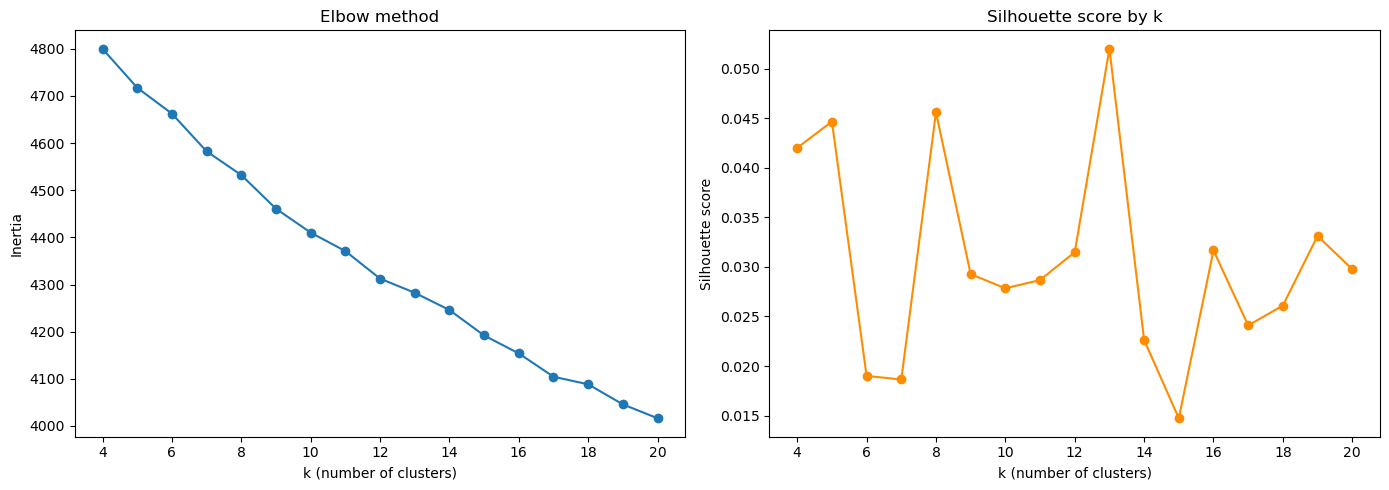

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")

plt.tight_layout()
plt.show()

*(Add your observation: where is the elbow, roughly? Which k maximizes silhouette score? Do the two methods agree, or point to different k? Pick your K_MEANS_K below based on this.)*

In [4]:
K_MEANS_K = 10  # adjust based on your observation above

kmeans_final = KMeans(n_clusters=K_MEANS_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(svd_embeddings)

kmeans_sil = silhouette_score(svd_embeddings[sample_idx], kmeans_labels[sample_idx])
print(f"Final K-Means (k={K_MEANS_K}) silhouette score: {kmeans_sil:.4f}")
print("\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

Final K-Means (k=10) silhouette score: 0.0278

Cluster sizes:
0     1090
1     1053
2      840
3     2097
4     1462
5      877
6     2667
7    10902
8     5450
9     3562
Name: count, dtype: int64


In [5]:
import umap

reducer_clustering = umap.UMAP(n_components=15, random_state=42, n_neighbors=15, min_dist=0.0)
umap_for_clustering = reducer_clustering.fit_transform(svd_embeddings)

print("UMAP (15D, for clustering) shape:", umap_for_clustering.shape)

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (15D, for clustering) shape: (30000, 15)


## Part B: HDBSCAN

No need to choose a cluster count -- HDBSCAN finds it automatically based on density. The key parameter is `min_cluster_size` -- the smallest group of points HDBSCAN will consider a genuine cluster rather than noise.

In [11]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=400, min_samples=15)
hdbscan_labels = clusterer.fit_predict(umap_for_clustering)

n_clusters_found = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

print(f"HDBSCAN found {n_clusters_found} clusters")
print(f"Noise points (unclustered): {n_noise:,} ({100 * n_noise / len(hdbscan_labels):.1f}%)")

HDBSCAN found 20 clusters
Noise points (unclustered): 9,163 (30.5%)


In [12]:
# Silhouette score excluding noise points (silhouette score is undefined for noise-labeled points)
non_noise_mask = hdbscan_labels != -1
sample_non_noise = sample_idx[non_noise_mask[sample_idx]]

hdbscan_sil = silhouette_score(
    umap_for_clustering[sample_non_noise], hdbscan_labels[sample_non_noise] 
)
print(f"HDBSCAN silhouette score (excluding noise): {hdbscan_sil:.4f}")
print(f"K-Means silhouette score (k={K_MEANS_K}): {kmeans_sil:.4f}")

HDBSCAN silhouette score (excluding noise): 0.4547
K-Means silhouette score (k=10): 0.0278


*(Add your observation: how do the silhouette scores compare? Is the noise percentage reasonable, or too high/low? Remember higher silhouette is better, but also weigh interpretability and cluster count sensibility -- a technically higher score with 40 tiny clusters may be less useful than a slightly lower score with 10 coherent ones.)*

## Step 3: Visualize both on the UMAP 2D projection

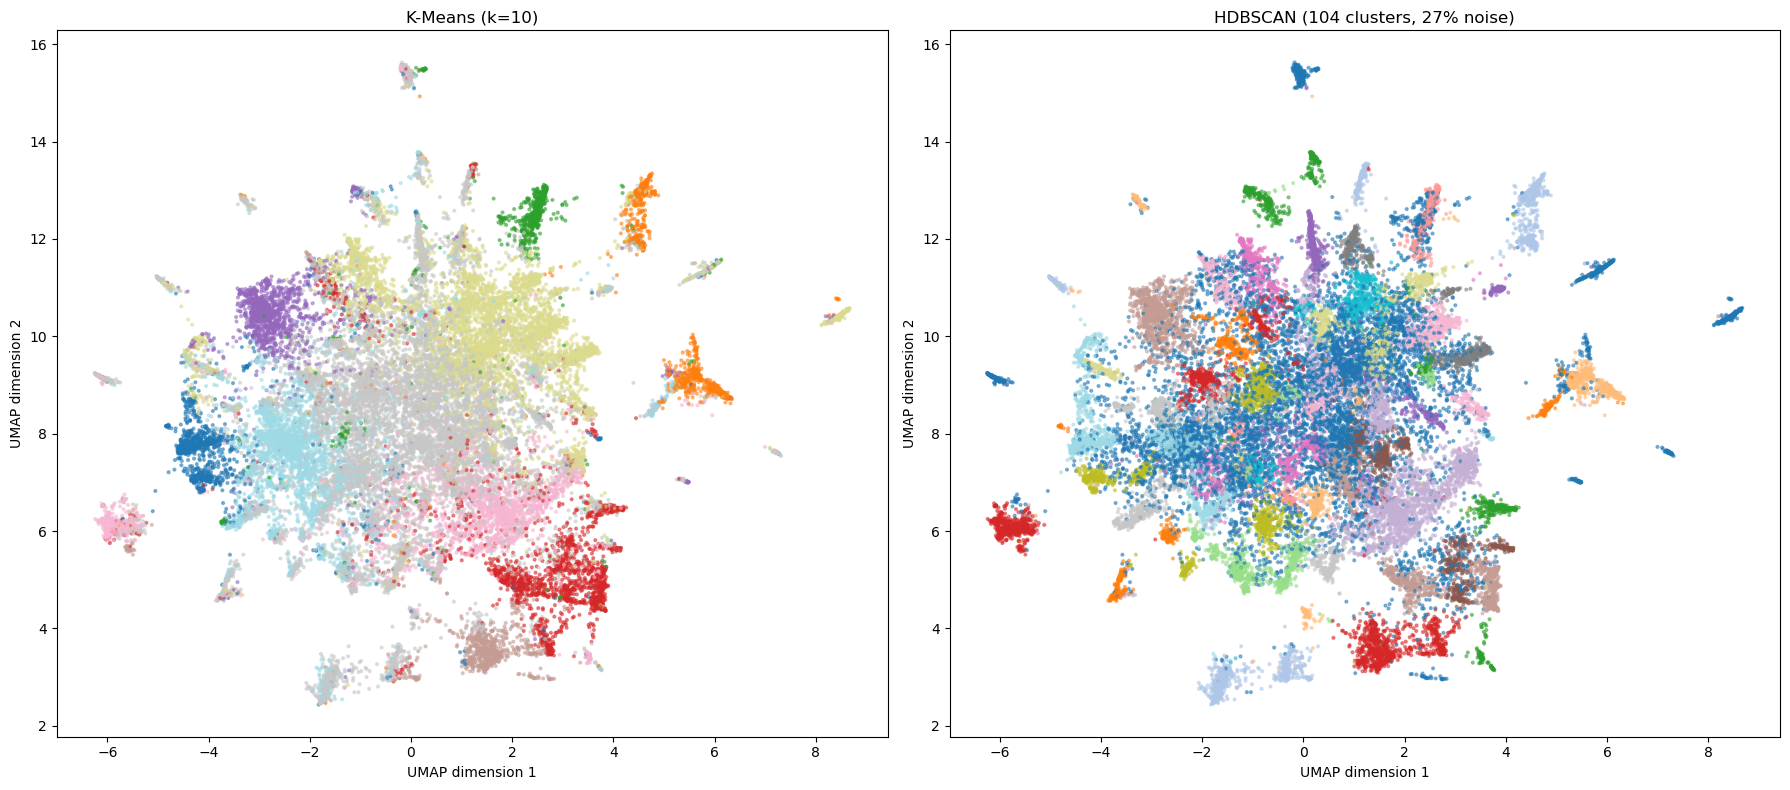

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

scatter1 = axes[0].scatter(
    umap_2d[:, 0], umap_2d[:, 1], c=kmeans_labels, cmap="tab20", s=4, alpha=0.5
)
axes[0].set_title(f"K-Means (k={K_MEANS_K})")
axes[0].set_xlabel("UMAP dimension 1")
axes[0].set_ylabel("UMAP dimension 2")

# For HDBSCAN, plot noise points in light gray, clusters in color
colors = np.where(hdbscan_labels == -1, -1, hdbscan_labels)
scatter2 = axes[1].scatter(
    umap_2d[:, 0], umap_2d[:, 1], c=colors, cmap="tab20", s=4, alpha=0.5
)
axes[1].set_title(f"HDBSCAN ({n_clusters_found} clusters, {100*n_noise/len(hdbscan_labels):.0f}% noise)")
axes[1].set_xlabel("UMAP dimension 1")
axes[1].set_ylabel("UMAP dimension 2")

plt.tight_layout()
plt.show()

*(Add your observation: visually, which method's clusters better match the natural groupings you saw in Stage 5's plot? Does K-Means appear to awkwardly split the dense central mass? Does HDBSCAN cleanly separate the satellite groups you noticed before?)*

## Step 4: Choose a method and save cluster assignments for Stage 7

Based on the quantitative (silhouette) and visual comparison above, choose ONE method to carry forward for interpretation in Stage 7. Update `CHOSEN_METHOD` below (`"kmeans"` or `"hdbscan"`) and justify your choice in the markdown cell -- this decision and its justification is exactly the kind of critical assessment the case study asks for.

*(State your final decision here: which method are you carrying forward, and why? Reference both the silhouette scores and the visual comparison.)*

In [9]:
CHOSEN_METHOD = "hdbscan"  # or "kmeans" -- set based on your decision above

df["cluster_kmeans"] = kmeans_labels
df["cluster_hdbscan"] = hdbscan_labels
df["cluster_final"] = df["cluster_hdbscan"] if CHOSEN_METHOD == "hdbscan" else df["cluster_kmeans"]

df.to_parquet("../data/processed/arxiv_clustered.parquet")
joblib.dump(kmeans_final, "../data/processed/kmeans_model.joblib")
joblib.dump(clusterer, "../data/processed/hdbscan_model.joblib")

print(f"Chosen method: {CHOSEN_METHOD}")
print("Saved: arxiv_clustered.parquet (with cluster_kmeans, cluster_hdbscan, cluster_final columns)")
print("Saved: kmeans_model.joblib, hdbscan_model.joblib")

Chosen method: hdbscan
Saved: arxiv_clustered.parquet (with cluster_kmeans, cluster_hdbscan, cluster_final columns)
Saved: kmeans_model.joblib, hdbscan_model.joblib
